# Initial Exploration and feature engineering of peptide retention dataset

**Initial exploration of dataset**

In [1]:
import pandas as pd 
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Load in data
peptide_df = pd.read_csv('../data/peptide_retention.csv')
print(peptide_df.shape)
peptide_df.head()

(10000, 4)


,ID,PeptideSequence,Modifications,RetentionTime
0,66442,EELNAISGPNEFAEFYDR,NaN,76.808103
1,9346,VPAQSESVR,NaN,-35.365414
2,87137,SEPEDPVTER,NaN,-12.258285
3,31419,SIRPGLSPYR,NaN,-0.953151
4,93265,NLINEMLTINPAK,NaN,88.572770


In [3]:
peptide_df.dtypes

ID                   int64
PeptideSequence     object
Modifications       object
RetentionTime      float64
dtype: object

In [4]:
#Look for missing values
for col in peptide_df.columns:
    print(f' Column: {col}, missing values: {sum(peptide_df[col].isna())}')
#Every peptide has id, sequence and retention time - but not all have modifications

 Column: ID, missing values: 0
 Column: PeptideSequence, missing values: 0
 Column: Modifications, missing values: 9175
 Column: RetentionTime, missing values: 0


In [5]:
#Check that only standard amino acids are present
allowed_aa = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S','T', 'V', 'W', 'Y']

for sequence in peptide_df['PeptideSequence']:
    invalid_aa = [aa for aa in sequence if aa not in allowed_aa]
    if invalid_aa:
        print(f'Sequence {sequence} has non standard amino acids: {invalid_aa}')
#All sequences made of standard amino acids

In [6]:
#Look for duplicates
peptide_df[peptide_df['ID'].duplicated(keep = False)]
#No duplicate IDs

,ID,PeptideSequence,Modifications,RetentionTime


In [7]:
#Look for duplicate sequences
duplicates_df = peptide_df[peptide_df['PeptideSequence'].duplicated(keep = False)]
duplicates_df

,ID,PeptideSequence,Modifications,RetentionTime
109,7361,MGVEAVIALLEATPDTPACVVSLNGNHAVR,1|Oxidation,115.702983
212,102841,VVDLMAHMASKE,8|Oxidation,-0.110702
270,111655,FASHCLMNHPDLAK,NaN,2.490344
315,82552,MLGTEGGEGFVVK,1|Oxidation,57.485420
324,18220,LQDEIQNMKEEMAR,8|Oxidation,-7.436920
...,...,...,...,...
9535,93018,MVYLLECLQK,1|Oxidation,61.225649
9605,99592,MVYLLECLQK,NaN,74.241480
9645,99294,YMLLPNQVWDSIIEQATK,NaN,140.923742
9776,48531,TYFSCTSAHTSTGDGTAMITR,NaN,21.351625


In [8]:
duplicates_df.groupby('PeptideSequence').size().sort_values(ascending = False)
#63 peptides have multiple retention times

PeptideSequence
LQDEIQNMKEEMAR                    3
AAAMVPGR                          2
MEQVNELKEK                        2
MGVEAVIALLEATPDTPACVVSLNGNHAVR    2
MHLGLVIPK                         2
                                 ..
KISIPVDISDSDMMLNIINSSITTK         2
LDILDMFTEIK                       2
LEPMIVPDLDLK                      2
LGPHTVLTFIFLEQMNK                 2
YMLLPNQVWDSIIEQATK                2
Length: 63, dtype: int64

In [9]:
duplicates_df[duplicates_df[['PeptideSequence', 'Modifications']].duplicated()]
#No duplicate peptides also have the same modifications

,ID,PeptideSequence,Modifications,RetentionTime


In [10]:
#Assess whether duplicate sequences have the similar retention times
diff_df = duplicates_df.groupby('PeptideSequence')['RetentionTime'].agg(['min', 'max']) 
diff_df['range'] = diff_df['max'] - diff_df['min']
diff_df.describe()
#Minimum range value is 0.02 - No duplicated sequences have exactly the same retention time
#Modification can have a significant effect

,min,max,range
count,63.000000,63.000000,63.000000
mean,61.068815,77.016344,15.947529
std,46.559008,43.224553,8.759859
min,-44.830909,-11.158850,0.024017
25%,27.732981,40.558751,11.162183
50%,64.710497,78.839242,14.420661
75%,94.560484,113.422902,21.984891
max,142.702491,144.351024,36.995521


In [11]:
#List the possible modifications
peptide_df['Modifications'].unique()

array([nan, '1|Acetyl', '4|Oxidation', '10|Oxidation', '6|Oxidation',
       '2|Oxidation', '8|Oxidation', '7|Oxidation', '13|Oxidation',
       '9|Oxidation', '1|Oxidation', '3|Oxidation', '16|Oxidation',
       '15|Oxidation', '14|Oxidation', '11|Oxidation', '29|Oxidation',
       '5|Oxidation', '30|Oxidation', '19|Oxidation', '12|Oxidation',
       '20|Oxidation', '27|Oxidation', '23|Oxidation', '18|Oxidation',
       '24|Oxidation', '25|Oxidation', '21|Oxidation', '17|Oxidation',
       '22|Oxidation', '4|Oxidation|13|Oxidation',
       '2|Oxidation|3|Oxidation', '1|Oxidation|2|Oxidation',
       '3|Oxidation|11|Oxidation', '1|Oxidation|6|Oxidation',
       '36|Oxidation', '2|Oxidation|9|Oxidation',
       '10|Oxidation|17|Oxidation', '5|Oxidation|7|Oxidation',
       '26|Oxidation', '4|Oxidation|10|Oxidation',
       '4|Oxidation|5|Oxidation', '2|Oxidation|10|Oxidation',
       '5|Oxidation|8|Oxidation', '7|Oxidation|10|Oxidation',
       '11|Oxidation|22|Oxidation', '1|Oxidation|

In [12]:
#Since only oxidation and acetyl modification are present count the amount for each peptide
peptide_df['oxidation_count'] = peptide_df['Modifications'].str.count('Oxidation').fillna(0)
peptide_df['acetyl_count'] = peptide_df['Modifications'].str.count('Acetyl').fillna(0)

# Feature Engineering

Based on know properties of amino acids such as size, charge and hydrophobicity we can create new features

<Axes: xlabel='RetentionTime', ylabel='Count'>

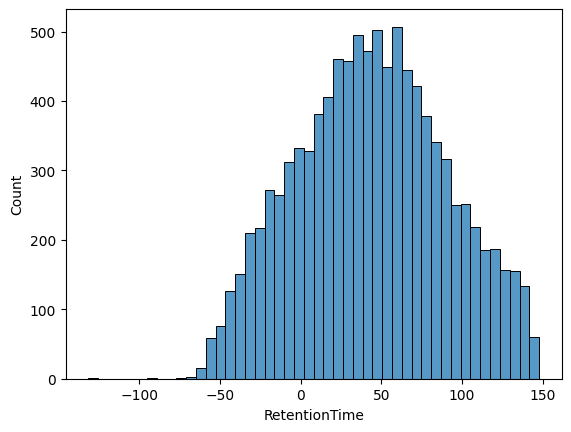

In [13]:
#Distribution of retention time 
sns.histplot(data = peptide_df, x = 'RetentionTime')
#retention time has been normalised

<Axes: xlabel='peptide_length', ylabel='Count'>

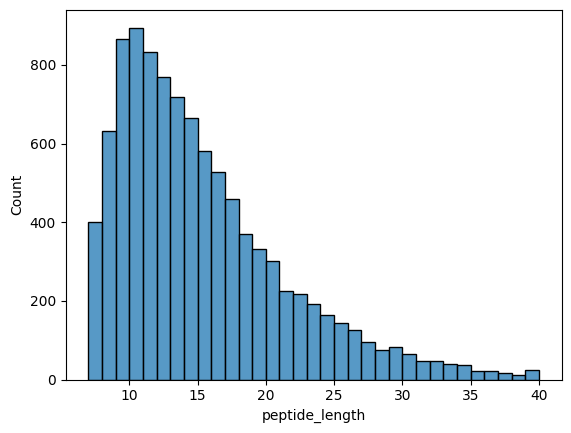

In [14]:
#Add length of peptide as column 
peptide_df['peptide_length'] = [len(string) for string in peptide_df['PeptideSequence']]
sns.histplot(data = peptide_df, x = 'peptide_length', binwidth=1)
#Peptide length is rightskewed

In [15]:
#Molecular information about each amino acid - from kaggle (https://www.kaggle.com/datasets/alejopaullier/aminoacids-physical-and-chemical-properties)
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alejopaullier/aminoacids-physical-and-chemical-properties")
amino_acid_df = pd.read_csv(f'{path}/aminoacids.csv')
amino_acid_df.head()

,Name,Abbr,Letter,Molecular Weight,Molecular Formula,Residue Formula,Residue Weight,pKa1,pKb2,pKx3,...,VSC,P1,P2,SASA,NCISC,carbon,hydrogen,nitrogen,oxygen,sulfur
0,Alanine,Ala,A,89.10,C3H7NO2,C3H5NO,71.08,2.34,9.69,NaN,...,27.5,8.1,0.046,1.181,0.007187,3,7,1,2,0
1,Cysteine,Cys,C,121.16,C3H7NO2S,C3H5NOS,103.15,1.96,10.28,8.18,...,44.6,5.5,0.128,1.461,-0.036610,3,7,1,2,1
2,Aspartic acid,Asp,D,133.11,C4H7NO4,C4H5NO3,115.09,1.88,9.60,3.65,...,40.0,13.0,0.105,1.587,-0.023820,4,7,1,4,0
3,Glutamic acid,Glu,E,147.13,C5H9NO4,C5H7NO3,129.12,2.19,9.67,4.25,...,62.0,12.3,0.151,1.862,0.006802,5,9,1,4,0
4,Phenylalanine,Phe,F,165.19,C9H11NO2,C9H9NO,147.18,1.83,9.13,NaN,...,115.5,5.2,0.290,2.228,0.037552,9,11,1,2,0


In [16]:
amino_acid_df.columns

Index(['Name', 'Abbr', 'Letter', 'Molecular Weight', 'Molecular Formula',
       'Residue Formula', 'Residue Weight', 'pKa1', 'pKb2', 'pKx3', 'pl4', 'H',
       'VSC', 'P1', 'P2', 'SASA', 'NCISC', 'carbon', 'hydrogen', 'nitrogen',
       'oxygen', 'sulfur'],
      dtype='object')

In [17]:
#For hydrophobicity (H), Solvent asscessible surface areas (SASA), voume of side chain (VSC)
#Use mean across sequence as most useful aggregation 
hydrophobicity_dict = amino_acid_df.set_index('Letter')['H'].to_dict()
sasa_dict = amino_acid_df.set_index('Letter')['SASA'].to_dict()
vsc_dict = amino_acid_df.set_index('Letter')['VSC'].to_dict()

def get_mean_values(string, metrics_dict):
    values = []
    
    for aa in string:
        values.append(metrics_dict[aa])

    return np.mean(values)

peptide_df['mean_hydrophobicity'] = peptide_df['PeptideSequence'].apply(get_mean_values, metrics_dict=hydrophobicity_dict)
peptide_df['mean_sasa'] = peptide_df['PeptideSequence'].apply(get_mean_values, metrics_dict=sasa_dict)
peptide_df['mean_vsc'] = peptide_df['PeptideSequence'].apply(get_mean_values, metrics_dict=vsc_dict)

In [18]:
#For residual weight - Total is better than mean 
rw_dict = amino_acid_df.set_index('Letter')['Residue Weight'].to_dict()

def get_sum_values(string, metrics_dict):
    values = []
    
    for aa in string:
        values.append(metrics_dict[aa])

    return np.sum(values)

peptide_df['total_residual_weight'] = peptide_df['PeptideSequence'].apply(get_sum_values, metrics_dict=rw_dict)

In [19]:
#Also add the N and C terminus residues
def get_first_and_last_aa(string):
    return (string[0], string[len(string)-1])

first_and_last_list = [get_first_and_last_aa(string) for string in peptide_df['PeptideSequence']]

first_and_last_df = pd.DataFrame(first_and_last_list, index = peptide_df.index)

peptide_df[['n_terminal', 'c_terminal']] = first_and_last_df

In [20]:
#Add flag if modification present
peptide_df['modification_present'] = ~peptide_df['Modifications'].isna()

In [21]:
peptide_df

,ID,PeptideSequence,Modifications,RetentionTime,oxidation_count,acetyl_count,peptide_length,mean_hydrophobicity,mean_sasa,mean_vsc,total_residual_weight,n_terminal,c_terminal,modification_present
0,66442,EELNAISGPNEFAEFYDR,NaN,76.808103,0.0,0.0,18,-0.067222,1.748833,65.105556,2083.25,E,R,False
1,9346,VPAQSESVR,NaN,-35.365414,0.0,0.0,9,-0.175556,1.654333,57.633333,954.06,V,R,False
2,87137,SEPEDPVTER,NaN,-12.258285,0.0,0.0,10,-0.456000,1.713700,56.690000,1140.20,S,R,False
3,31419,SIRPGLSPYR,NaN,-0.953151,0.0,0.0,10,-0.200000,1.764200,65.670000,1127.33,S,R,False
4,93265,NLINEMLTINPAK,NaN,88.572770,0.0,0.0,13,0.125385,1.751923,71.300000,1452.78,N,K,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,43305,LCNSLEESIR,NaN,18.683235,0.0,0.0,10,-0.136000,1.766800,67.140000,1145.33,L,R,False
9996,17792,RPFGVAVMDITDIIHGK,NaN,80.462639,0.0,0.0,17,0.208824,1.702059,65.752941,1851.22,R,K,False
9997,16249,LRPQTYDLQESNVQLK,NaN,24.938680,0.0,0.0,16,-0.286875,1.863437,74.975000,1914.18,L,K,False
9998,101011,LPPVLSHPIFDDR,NaN,57.474966,0.0,0.0,13,0.093846,1.769692,68.192308,1487.74,L,R,False


**Exploration of the relationship between newly engineered features and retention time**

In [22]:
feature_columns = ['peptide_length', 
                   'mean_hydrophobicity', 
                   'mean_sasa', 
                   'mean_vsc', 
                   'total_residual_weight', 
                   'oxidation_count',
                   'acetyl_count',
                  'modification_present']

for f in feature_columns:
    corr = peptide_df[f].corr(peptide_df['RetentionTime'], method='spearman') #Spearman as no assumption of normality
    print(f'{f}: {corr}')
#Strong correlation between peptide length, mean_hydrophobicity, total residual weight and retention time

peptide_length: 0.5792694712789958
mean_hydrophobicity: 0.5528107013261211
mean_sasa: 0.031172362250578633
mean_vsc: 0.16448988883806198
total_residual_weight: 0.6063076463626372
oxidation_count: 0.06251277908926443
acetyl_count: 0.035023565279059365
modification_present: 0.0725717562839536


<Axes: >

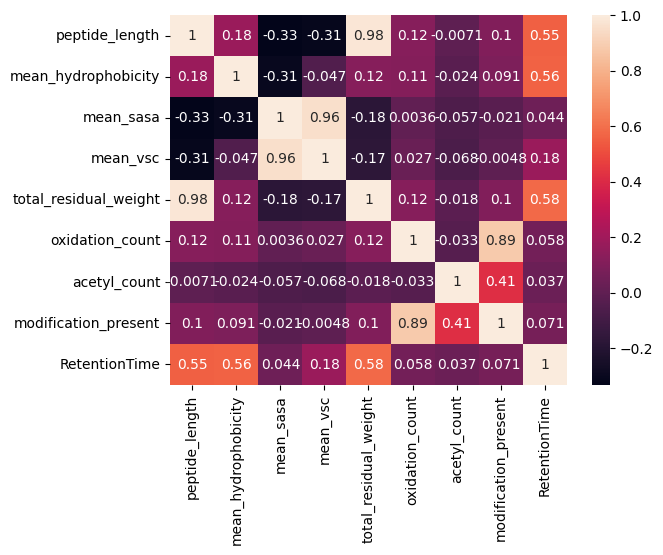

In [23]:
#General plot of correlation between numeric features
plot_df = peptide_df[feature_columns + ['RetentionTime']]
corr_matrix = plot_df.corr()

sns.heatmap(corr_matrix, annot = True)

**Why peptide length, mean hydrophobicity and total residual weight correlate with retention time**

Retention time in LC is driven by how strongly a peptide interacts with the hydrophobic stationary phase of the column - stronger interactions mean later elution

**Mean hydrophobicity** - Hydrophobic peptides elute later so strong correlation makes sense and is a good sanity check

**Peptide length** - Longer peptides have more surface area interacting with the column and more likely to contain hydrophobic residues 

**Total residual weight** - Likely a proxy for length - heavier peptides are almost always longer

Mean vsc is also highly correlated with mean sasa - This makes scientific sense as larger side chains naturally expose more solvent accesssible area. Neither are highly correlated with retention time however. 

Given these findings the data looks sound and modelling makes sense. Given the high redundacy betweeen peptide length and residual weight, it makes sense to only keep peptide length as it is more interpretable. Mean VSC and Mean SASA also are similarly redundant, so mean VSC will be dropped as mean SASA related more to how the surface of the peptide interacts with the column

In [24]:
#Save for modelling 
peptide_df = peptide_df.drop(['mean_vsc', 'total_residual_weight'], axis = 1)
peptide_df.to_csv('../data/peptides_modelling_df.csv', index = False)

**What I would do next**

Visualise key relationships between mean hydrophobicity, peptide length and total residual weight and retention time - Could reveal a non linear relationship

Investigate further the effect of modifications on retention time of duplicate sequences - See what effect these modifications have